---
## TS1: Ejercicio 1 — Síntesis de señales

En este ejercicio se sintetizan seis señales con distintas características.  
Para cada una se indica: período, número de muestras y si es una señal de potencia o de energía.

### Parámetros comunes

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import square

fs = 44100          # frecuencia de muestreo
N  = 1000           # número de muestras
tt = (np.arange(N) / fs).reshape(N, 1)   # vector de tiempo

vmax = 1.0          # amplitud de la señal
f1   = 2000         # frecuencia de la señal base

### Señal 1 — Sinusoidal de 2 kHz

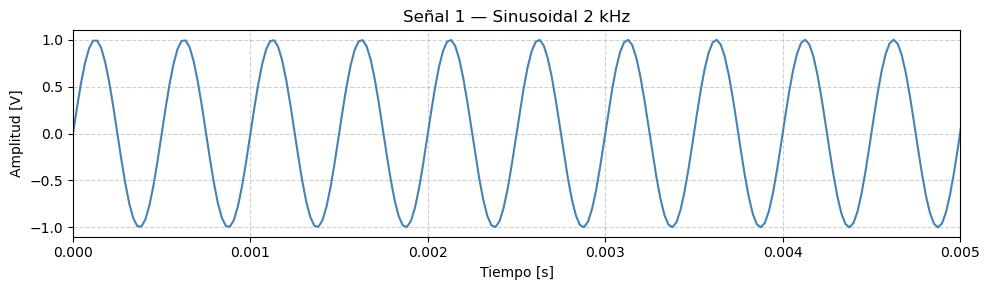

In [ ]:
xx1 = vmax * np.sin(2 * np.pi * f1 * tt)

plt.figure(figsize=(10, 3))
plt.plot(tt, xx1, color='steelblue', linewidth=1.5)
plt.title('Señal 1 — Sinusoidal 2 kHz')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.xlim([0, 0.005])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Análisis — Señal 1**

| Parámetro | Valor |
|---|---|
| Período | $T = 1/f = 1/2000 = 0{,}5 \ \text{ms}$ |
| Número de muestras totales | $N = 1000$ |
| Muestras por período | $N_T = f_s / f = 44100 / 2000 \approx 22$ muestras/ciclo |
| Tipo de señal | Señal de potencia |

Es una señal de potencia porque es periódica: su energía es infinita pero su potencia media es finita ($P = V_{max}^2 / 2 = 0{,}5 \ \text{W}$).

### Señal 2 — Misma señal amplificada 3 dB y desfasada π/2

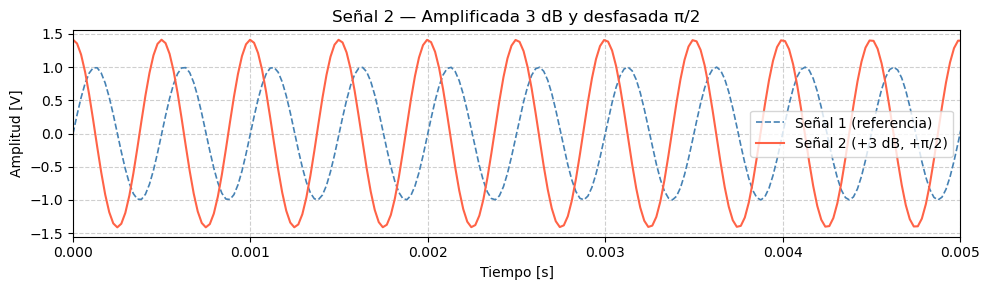

In [ ]:
vmax2 = vmax * 10**(3/20)
ph2   = np.pi / 2

xx2 = vmax2 * np.sin(2 * np.pi * f1 * tt + ph2)

plt.figure(figsize=(10, 3))
plt.plot(tt, xx1, color='steelblue', linewidth=1.2, linestyle='--', label='Señal 1 (referencia)')
plt.plot(tt, xx2, color='tomato',    linewidth=1.5, label='Señal 2 (+3 dB, +π/2)')
plt.title('Señal 2 — Amplificada 3 dB y desfasada π/2')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.xlim([0, 0.005])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Análisis — Señal 2**

| Parámetro | Valor |
|---|---|
| Período | $T = 0{,}5 \ \text{ms}$ (misma frecuencia) |
| Número de muestras totales | $N = 1000$ |
| Muestras por período | $\approx 22$ muestras/ciclo |
| Tipo de señal | Señal de potencia |

La amplificación de 3 dB equivale a multiplicar la amplitud por $\sqrt{2} \approx 1{,}414$.  
El desfase de $\pi/2$ convierte el seno en coseno: $\sin(\omega t + \pi/2) = \cos(\omega t)$.  
Al ser periódica, sigue siendo señal de potencia ($P = V_{max2}^2 / 2 = 1 \ \text{W}$).

### Señal 3 — Modulación en amplitud (AM)

La portadora es la señal sinusoidal de 2 kHz del ítem 1.1 ($V_{max} = 1$, sin desfase).  
La señal modulante es una sinusoidal cuya frecuencia especifica la consigna.

$$x_{AM}(t) = V_{max} \cdot \left[1 + m \cdot \sin(2\pi f_m t)\right] \cdot \sin(2\pi f_1 t)$$

donde $m$ es el índice de modulación (se usa $m = 1$ = 100 %).


**Nota sobre la frecuencia de muestreo y la frecuencia de la modulante**

La frecuencia de muestreo utilizada en todo el ejercicio es $f_s = 44100\ \text{Hz}$, la tasa estándar de audio digital. Esta elección es apropiada porque satisface el teorema de Nyquist para todas las señales del ejercicio: la de mayor frecuencia es la señal cuadrada de 4 kHz (ítem 1.5), que requiere $f_s > 8\ \text{kHz}$.

La consigna indica $f_m = 1000\ \text{KHz} = 1\ \text{MHz}$. Esta frecuencia es incompatible con el contexto del ejercicio por dos razones independientes:

1. Contexto de AM: en modulación en amplitud, la modulante debe tener una frecuencia considerablemente menor que la portadora ($f_m \ll f_1$). Con $f_1 = 2\ \text{kHz}$ y $f_m = 1\ \text{MHz}$, la modulante oscila 500 veces más rápido que la portadora, lo cual carece de sentido físico en AM.

2. Teorema de Nyquist: con $f_s = 44100\ \text{Hz}$, la máxima frecuencia representable es $f_s/2 = 22050\ \text{Hz}$. Una modulante de 1 MHz está completamente fuera de esa banda y solo produciría aliasing. Cabe aclarar que esta limitación no es una elección arbitraria: es consecuencia directa del rango de frecuencias del ejercicio (señales de audio).

Por lo tanto, se interpreta $f_m = 1000\ \text{KHz}$ como un error tipográfico, y se lo corrige a $f_m = 1000\ \text{Hz} = 1\ \text{kHz}$, que es coherente tanto con el rango de audio como con la condición $f_m < f_1$.

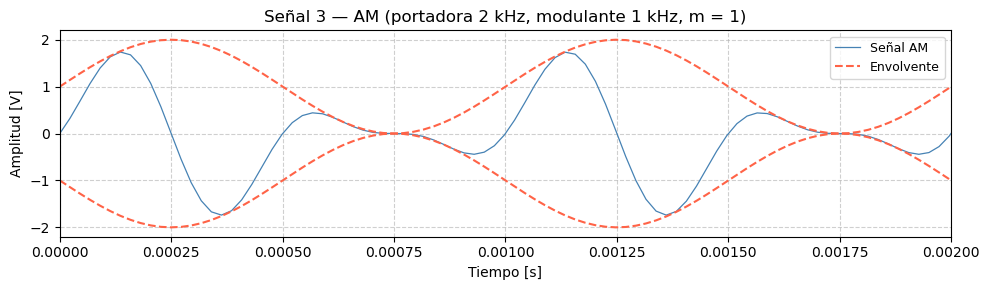

In [306]:
f_mod = 1000   # 1 kHz — ver nota en celda anterior
m     = 1.0    # índice de modulación (100 %)

mod  = np.sin(2 * np.pi * f_mod * tt)
xx3  = (1 + m * mod) * xx1

env_pos =  vmax * (1 + m * mod)
env_neg = -vmax * (1 + m * mod)

plt.figure(figsize=(10, 3))
plt.plot(tt, xx3,     color='steelblue', linewidth=0.9, label='Señal AM')
plt.plot(tt, env_pos, color='tomato',    linewidth=1.5, linestyle='--', label='Envolvente')
plt.plot(tt, env_neg, color='tomato',    linewidth=1.5, linestyle='--')
plt.title('Señal 3 — AM (portadora 2 kHz, modulante 1 kHz, m = 1)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.xlim([0, 0.002])
plt.legend(fontsize=9)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Análisis — Señal 3**

| Parámetro | Valor |
|---|---|
| Período | $T = 1/\text{MCD}(f_1,\, f_m) = 1/\text{MCD}(2000,\,1000) = 1\ \text{ms}$ |
| Número de muestras totales | $N = 1000$ |
| Muestras por período | $f_s/f_m = 44100/1000 \approx 44\ \text{muestras/ciclo}$ |
| Tipo de señal | Señal de potencia |

La señal AM es periódica con período igual al de la modulante (la componente de menor frecuencia).  
Sus componentes espectrales se encuentran en $f_1 - f_m = 1\ \text{kHz}$, $f_1 = 2\ \text{kHz}$ y $f_1 + f_m = 3\ \text{kHz}$.

### Señal 4 — Señal con saturación al 75% de su amplitud

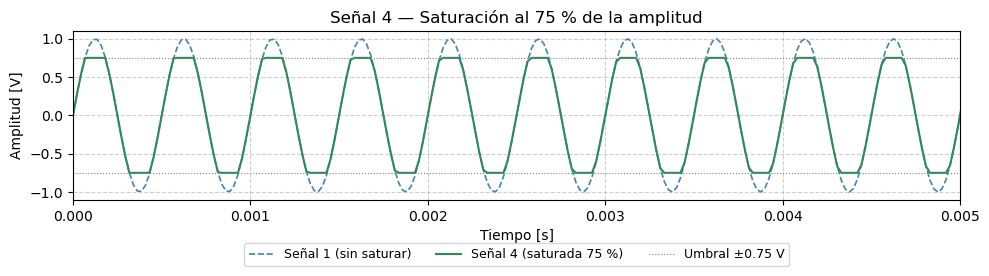

In [307]:
clip_val = 0.75 * vmax      # umbral de saturación

xx4 = np.clip(xx1, -clip_val, clip_val)

plt.figure(figsize=(10, 3))
plt.plot(tt, xx1, color='steelblue', linewidth=1.2, linestyle='--', label='Señal 1 (sin saturar)')
plt.plot(tt, xx4, color='seagreen',  linewidth=1.5,                  label='Señal 4 (saturada 75 %)')
plt.axhline( clip_val, color='gray', linewidth=0.8, linestyle=':', label=f'Umbral ±{clip_val:.2f} V')
plt.axhline(-clip_val, color='gray', linewidth=0.8, linestyle=':')
plt.title('Señal 4 — Saturación al 75 % de la amplitud')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.xlim([0, 0.005])
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=3, fontsize=9)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Análisis — Señal 4**

| Parámetro | Valor |
|---|---|
| Período | $T = 0{,}5 \ \text{ms}$ (misma frecuencia) |
| Número de muestras totales | $N = 1000$ |
| Muestras por período | $\approx 22$ muestras/ciclo |
| Tipo de señal | Señal de potencia |

Limito la señal al intervalo $[-0{,}75V_{max},\ +0{,}75V_{max}]$ con numpy.clip().  
El resultado es una señal periódica con los picos recortados.  
Al seguir siendo periódica, mantiene su carácter de señal de potencia.

### Señal 5 — Señal cuadrada de 4 kHz

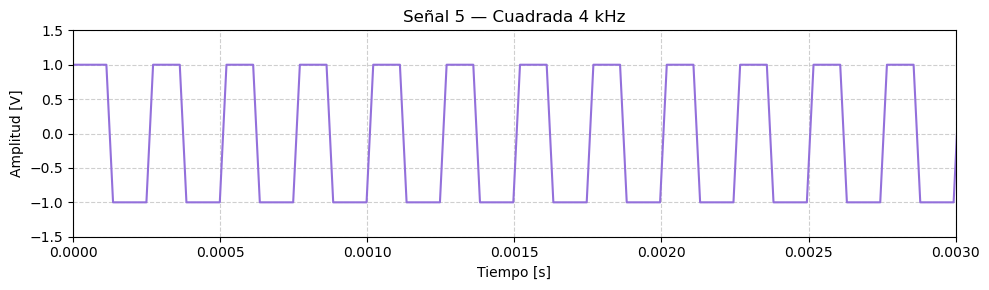

In [ ]:
f2  = 4000      # frecuencia de la señal cuadrada [Hz]

xx5 = square(2 * np.pi * f2 * tt)

plt.figure(figsize=(10, 3))
plt.plot(tt, xx5, color='mediumpurple', linewidth=1.5)
plt.title('Señal 5 — Cuadrada 4 kHz')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.xlim([0, 0.003])
plt.ylim([-1.5, 1.5])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Análisis — Señal 5**

| Parámetro | Valor |
|---|---|
| Período | $T = 1/f = 1/4000 = 0{,}25 \ \text{ms}$ |
| Número de muestras totales | $N = 1000$ |
| Muestras por período | $f_s / f = 44100 / 4000 \approx 11$ muestras/ciclo |
| Tipo de señal | Señal de potencia |

La señal cuadrada es periódica y puede expandirse como serie de Fourier de sinusoides impares.  
Su potencia media es $P = V_{max}^2 = 1 \ \text{W}$ (alterna entre $+1$ y $-1$ con igual duración).

### Señal 6 — Pulso rectangular de 10 ms

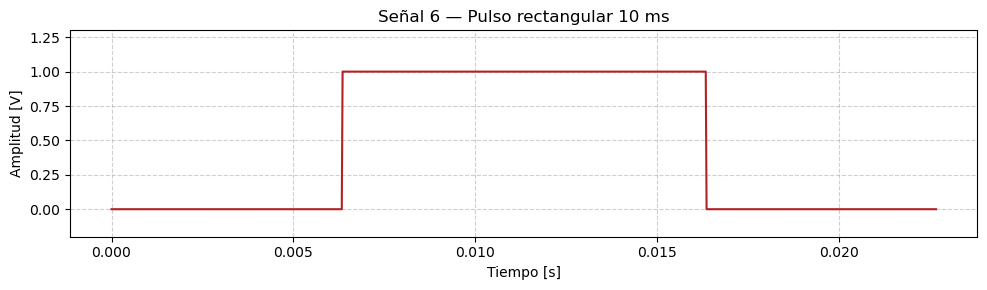

In [309]:
tau      = 0.010                         # duración 10 seg
t_inicio = (N / fs - tau) / 2            # centrado en el intervalo de observación

xx6     = np.where((tt >= t_inicio) & (tt <= t_inicio + tau), 1.0, 0.0)
N_pulso = int(tau * fs)                  # muestras del pulso

plt.figure(figsize=(10, 3))
plt.plot(tt, xx6, color='firebrick', linewidth=1.5)
plt.title('Señal 6 — Pulso rectangular 10 ms')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.ylim([-0.2, 1.3])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Análisis — Señal 6**

| Parámetro | Valor |
|---|---|
| Período | **Aperiódica** — no tiene período definido |
| Duración del pulso | $\tau = 10 \ \text{ms}$ |
| Número de muestras totales | $N = 1000$ |
| Muestras dentro del pulso | $N_{\tau} = \tau \cdot f_s = 0{,}01 \times 44100 = 441$ muestras |
| Tipo de señal | Señal de energía |

El pulso rectangular tiene duración finita, por lo que su energía es finita:

$$E = V_{max}^2 \cdot \tau = 1^2 \times 0{,}01 = 0{,}01 \ \text{J}$$

Su potencia media sobre un intervalo infinito tiende a cero ($P \to 0$), lo que la clasifica como señal de energía.

---
## TS1: Ejercicio 2 — Convolución con $h[n] = \delta[n] - \delta[n-4]$

### Simplificación general

Aplicando la propiedad del impulso ($x[n] * \delta[n-k] = x[n-k]$):

$$y[n] = x[n] * h[n] = x[n] * \delta[n] - x[n] * \delta[n-4] = \boxed{x[n] - x[n-4]}$$

Esta relación se usa en los tres incisos.

### a) $x[n] = \cos(\omega_0 n T_s)$

**Desarrollo**

$$y[n] = \cos(\omega_0 n T_s) - \cos(\omega_0 (n-4) T_s)$$

Se factoriza usando la respuesta en frecuencia del filtro evaluada en $\omega = \omega_0 T_s$:

$$H(e^{j\omega_0 T_s}) = 1 - e^{-j4\omega_0 T_s}$$

Factorizando:

$$= e^{-j2\omega_0 T_s}\left(e^{j2\omega_0 T_s} - e^{-j2\omega_0 T_s}\right) = 2j\sin(2\omega_0 T_s)\,e^{-j2\omega_0 T_s} = 2\sin(2\omega_0 T_s)\cdot e^{j\left(\frac{\pi}{2} - 2\omega_0 T_s\right)}$$

La salida para una entrada coseno en un sistema LTI es $y[n] = |H|\cdot\cos(\omega_0 n T_s + \angle H)$, con:

$$A = |H(e^{j\omega_0 T_s})| = 2|\sin(2\omega_0 T_s)|$$

$$\varphi = \angle H(e^{j\omega_0 T_s}) = \begin{cases} \dfrac{\pi}{2} - 2\omega_0 T_s & \text{si } \sin(2\omega_0 T_s) \ge 0 \\[6pt] \dfrac{3\pi}{2} - 2\omega_0 T_s & \text{si } \sin(2\omega_0 T_s) < 0 \end{cases}$$

$$\boxed{y[n] = 2|\sin(2\omega_0 T_s)|\cdot\cos(\omega_0 n T_s + \varphi)}$$

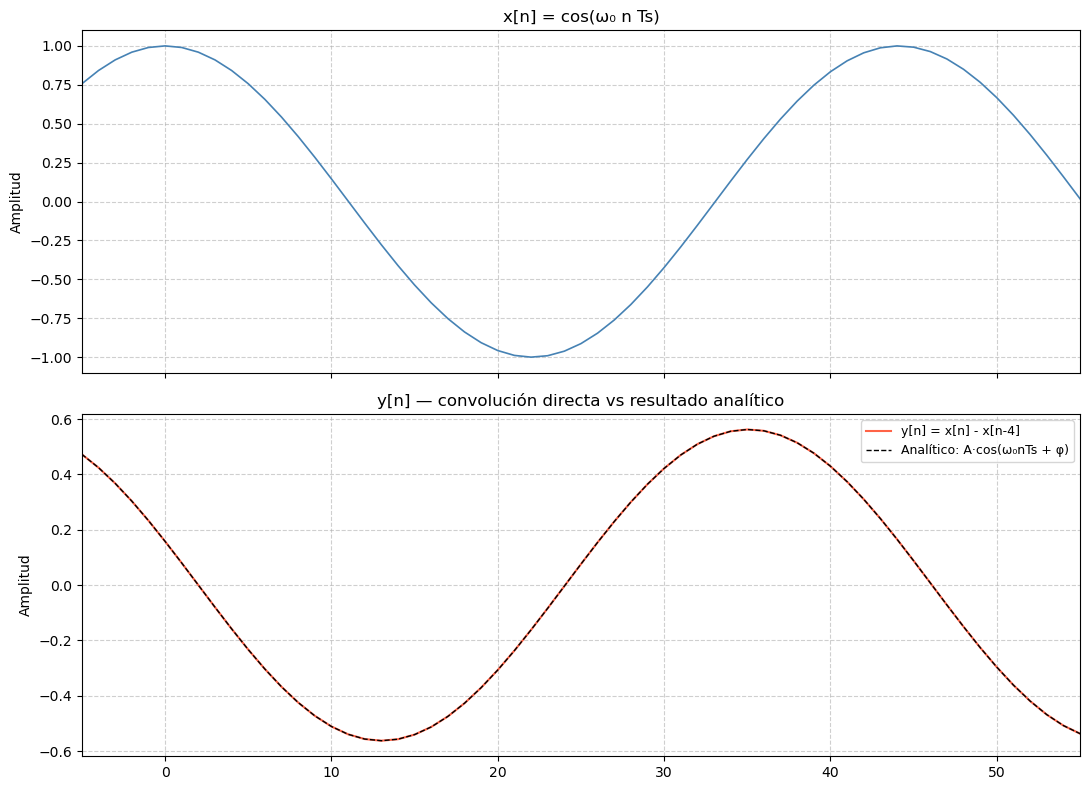

In [310]:
# Parámetros — verificación numérica con f0=1000 Hz, fs=44100 Hz
fs     = 44100
Ts     = 1 / fs
omega0 = 2 * np.pi * 1000          # 1 kHz

n = np.arange(-10, 60)

# Señal de entrada y convolución directa y[n] = x[n] - x[n-4]
x_a = np.cos(omega0 * n * Ts)
y_a = np.cos(omega0 * n * Ts) - np.cos(omega0 * (n - 4) * Ts)

# Resultado analítico: A y phi calculados desde H(e^jw)
H_val = 1 - np.exp(-1j * 4 * omega0 * Ts)
A     = np.abs(H_val)
phi   = np.angle(H_val)
y_a_analitico = A * np.cos(omega0 * n * Ts + phi)

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

axes[0].plot(n, x_a, color='steelblue', linewidth=1.2)
axes[0].set_title('x[n] = cos(ω₀ n Ts)')
axes[0].set_ylabel('Amplitud')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_xlim([-5, 55])

axes[1].plot(n, y_a, color='tomato', linewidth=1.5, label='y[n] = x[n] - x[n-4]')
axes[1].plot(n, y_a_analitico, 'k--', linewidth=1.0, label='Analítico: A·cos(ω₀nTs + φ)')
axes[1].set_title('y[n] — convolución directa vs resultado analítico')
axes[1].set_ylabel('Amplitud')
axes[1].legend(fontsize=9)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**Análisis de los resultados a)**

Actúa como un filtro sobre la sinusoide de entrada. La respuesta en frecuencia $H(e^{j\omega_0 T_s})$ escala la amplitud y agrega una fase constante:  

- Amplitud: $A = 2|\sin(2\omega_0 T_s)|$ — depende de la frecuencia de la señal de entrada.  
- Fase: $\varphi = \frac{\pi}{2} - 2\omega_0 T_s$ — desfase lineal con la frecuencia.

### b) $x[n] = \left(\tfrac{1}{2}\right)^n u[n]$

**Desarrollo**

$$y[n] = x[n] - x[n-4] = \left(\tfrac{1}{2}\right)^n u[n] - \left(\tfrac{1}{2}\right)^{n-4} u[n-4]$$

Analizando por casos:

| Rango de $n$ | $x[n]$ | $x[n-4]$ | $y[n]$ |
|---|---|---|---|
| $n < 0$ | $0$ | $0$ | $0$ |
| $0 \le n \le 3$ | $(\tfrac{1}{2})^n$ | $0$ | $(\tfrac{1}{2})^n$ |
| $n \ge 4$ | $(\tfrac{1}{2})^n$ | $(\tfrac{1}{2})^{n-4} = 2^4 \cdot (\tfrac{1}{2})^n$ | $(1 - 16)\,(\tfrac{1}{2})^n = -15\,(\tfrac{1}{2})^n$ |

$$\boxed{y[n] = \begin{cases} (\tfrac{1}{2})^n & 0 \le n \le 3 \\ -15\,(\tfrac{1}{2})^n & n \ge 4 \\ 0 & \text{resto} \end{cases}}$$

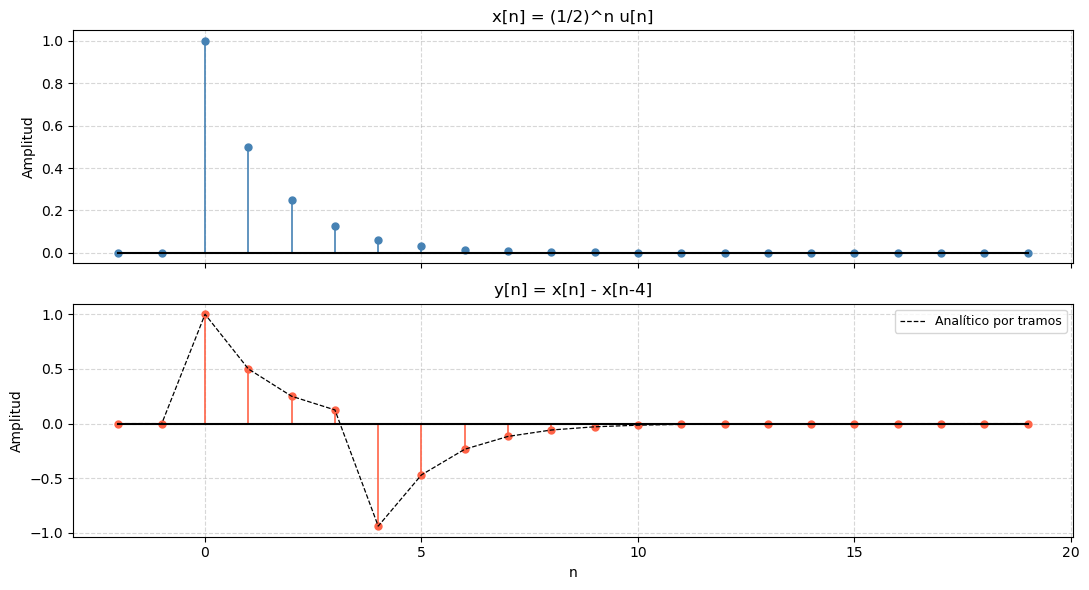

In [311]:
n_b = np.arange(-2, 20)

# x[n] = (1/2)^n u[n]
x_b   = np.where(n_b >= 0, (0.5)**n_b, 0.0)
# x[n-4] = (1/2)^(n-4) u[n-4]
x_b4  = np.where(n_b >= 4, (0.5)**(n_b - 4), 0.0)
y_b   = x_b - x_b4

# Resultado analítico por tramos
y_b_analitico = np.where(
    (n_b >= 0) & (n_b <= 3), (0.5)**n_b,
    np.where(n_b >= 4, -15 * (0.5)**n_b, 0.0)
)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

markerline, stemlines, baseline = axes[0].stem(n_b, x_b, linefmt='steelblue', markerfmt='o', basefmt='k-')
plt.setp(markerline, color='steelblue', markersize=5)
plt.setp(stemlines,  color='steelblue', linewidth=1.2)
axes[0].set_title('x[n] = (1/2)^n u[n]')
axes[0].set_ylabel('Amplitud')
axes[0].grid(True, linestyle='--', alpha=0.5)

markerline2, stemlines2, baseline2 = axes[1].stem(n_b, y_b, linefmt='tomato', markerfmt='o', basefmt='k-')
plt.setp(markerline2, color='tomato', markersize=5)
plt.setp(stemlines2,  color='tomato', linewidth=1.2)
axes[1].plot(n_b, y_b_analitico, 'k--', linewidth=0.9, label='Analítico por tramos')
axes[1].set_title('y[n] = x[n] - x[n-4]')
axes[1].set_ylabel('Amplitud')
axes[1].set_xlabel('n')
axes[1].legend(fontsize=9)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Análisis de los resultados b)**

- Para $0 \le n \le 3$: solo contribuye $x[n]$ ya que $x[n-4] = 0$. La señal de salida decae como $(1/2)^n$.  
- Para $n \ge 4$: ambas versiones contribuyen. Como $x[n-4] = 16 \cdot x[n]$, el término retardado domina y la salida cambia de signo y vale $-15\,(1/2)^n$.  
- La señal $y[n]$ es de energía (converge a cero exponencialmente).

### c) $x[n] = u[n+1] - u[n-2]$

**Identificación de x[n]**

$u[n+1] - u[n-2]$ es una ventana rectangular:

$$x[n] = 1 \quad \text{para} \quad n \in \{-1,\ 0,\ 1\}, \qquad x[n]=0 \text{ en otro caso}$$

**Desarrollo**

$$y[n] = x[n] - x[n-4]$$

- $x[n] = 1$ para $n \in \{-1, 0, 1\}$  
- $x[n-4] = 1$ para $n-4 \in \{-1, 0, 1\}$, es decir $n \in \{3, 4, 5\}$  

Como los soportes $\{-1,0,1\}$ y $\{3,4,5\}$ no se superponen:

$$\boxed{y[n] = \begin{cases} +1 & n \in \{-1,\ 0,\ 1\} \\ -1 & n \in \{3,\ 4,\ 5\} \\ 0 & \text{resto} \end{cases}}$$

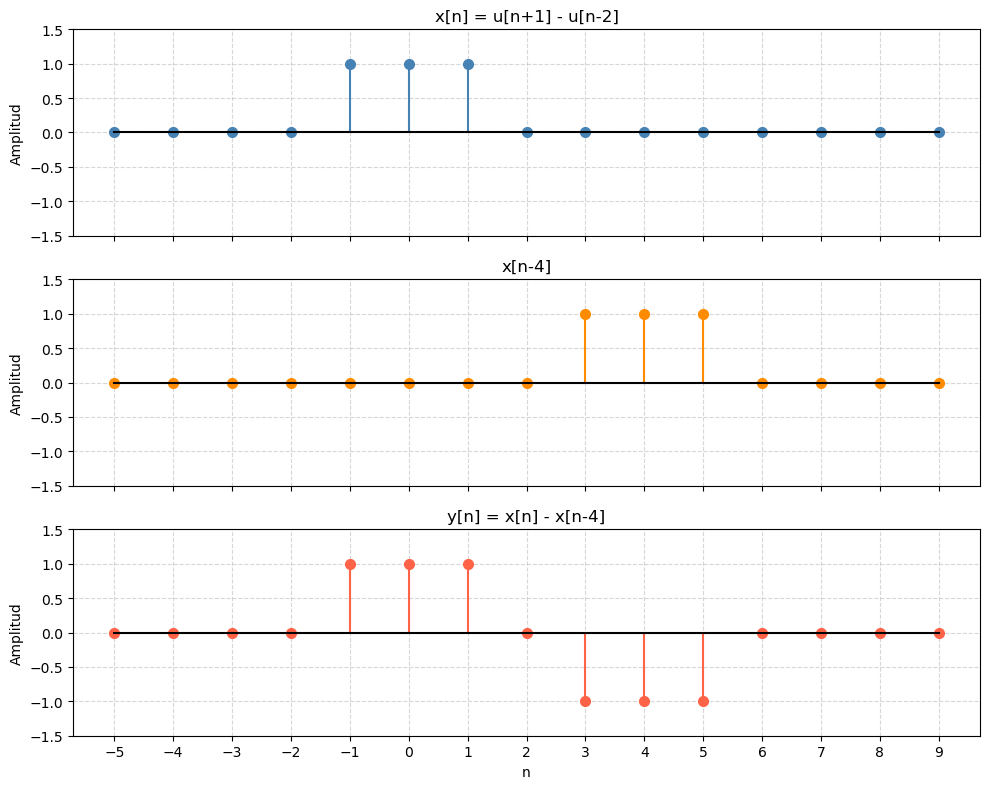

In [312]:
n_c = np.arange(-5, 10)

# x[n] = u[n+1] - u[n-2]
x_c  = np.where((n_c >= -1) & (n_c <= 1), 1.0, 0.0)
# x[n-4]
x_c4 = np.where(((n_c - 4) >= -1) & ((n_c - 4) <= 1), 1.0, 0.0)
y_c  = x_c - x_c4

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

for ax, sig, label, color in [
    (axes[0], x_c,  'x[n] = u[n+1] - u[n-2]', 'steelblue'),
    (axes[1], x_c4, 'x[n-4]',                  'darkorange'),
    (axes[2], y_c,  'y[n] = x[n] - x[n-4]',   'tomato'),
]:
    ml, sl, bl = ax.stem(n_c, sig, linefmt=color, markerfmt='o', basefmt='k-')
    plt.setp(ml, color=color, markersize=7)
    plt.setp(sl, color=color, linewidth=1.5)
    ax.set_title(label)
    ax.set_ylabel('Amplitud')
    ax.set_ylim([-1.5, 1.5])
    ax.set_xticks(n_c)
    ax.grid(True, linestyle='--', alpha=0.5)

axes[2].set_xlabel('n')
plt.tight_layout()
plt.show()

**Análisis de los resultados c)**

- $x[n]$ es un pulso rectangular de 3 muestras ($n = -1, 0, 1$).  
- $x[n-4]$ es el mismo pulso desplazado 4 posiciones hacia la derecha ($n = 3, 4, 5$).  
- Como ambos soportes no se solapan, $y[n]$ es un pulso bipolar: vale $+1$ en el primer bloque y $-1$ en el segundo, con ceros en el resto.  
- $y[n]$ es una señal de energía => $E = 3\cdot1^2 + 3\cdot(-1)^2 = 6$.